In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q transformers datasets sentence-transformers faiss-cpu accelerate evaluate scikit-learn seaborn bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import torch
import re
import string
from datasets import load_dataset, DatasetDict
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import faiss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [4]:
dataset = load_dataset("nvidia/TechQA-RAG-Eval")

dataset = dataset['train'].train_test_split(test_size=0.2)

train_data = dataset['train']
test_data = dataset['test']

print(test_data[0])

README.md: 0.00B [00:00, ?B/s]

train.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/910 [00:00<?, ? examples/s]

{'id': 'TRAIN_Q592', 'question': 'Do the  Bash Bug  vulnerabilities affect WebSphere MQ Hypervisor?\n\nDo the Bourne Again Shell (Bash) vulnerabilities known as Bash Bugs or Shellshock affect WebSphere MQ Hypervisor and if so, what action is required to address this situation?', 'answer': 'IBM WebSphere MQ Hypervisor Edition for Red Hat Enterprise Linux Server ship with Red Hat Enterprise Linux (RHEL) that is vulnerable to CVE-2014-6271, CVE-2014-7169, CVE-2014-7186, CVE-2014-7187, CVE-2014-6277 and CVE-2014-6278 Bash vulnerabilities.', 'is_impossible': False, 'contexts': [{'filename': 'swg21685666.txt', 'text': 'Title: IBM Action required for IBM WebSphere MQ Hypervisor Edition for Red Hat Enterprise Linux Server for the Bash vulnerabilities (CVE-2014-6271, CVE-2014-7169, CVE-2014-7186, CVE-2014-7187, CVE-2014-6277 and CVE-2014-2014-6278) - United States\n\nText:\n FLASH (ALERT)\n\nABSTRACT\n IBM WebSphere MQ Hypervisor Edition for Red Hat Enterprise Linux Server requires customer act

In [5]:
embedder = SentenceTransformer('all-MiniLM-L6-v2')

corpus = []

for item in train_data:
    for ctx in item['contexts']:
        corpus.append(ctx['text'])

corpus = list(set(
    ctx['text']
    for item in train_data
    for ctx in item['contexts']
))

corpus_embeddings = embedder.encode(corpus, show_progress_bar=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

In [6]:
dimension = corpus_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(corpus_embeddings))

In [7]:
def retrieve_context(question, top_k=15):
    q_emb = embedder.encode([question])
    
    distances, indices = index.search(np.array(q_emb), top_k)
    
    retrieved = [corpus[i] for i in indices[0]]
    
    return retrieved, distances[0]

In [8]:
model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [9]:
def generate_answer(question, context):

    prompt = f"""
    Answer the question using ONLY the context.
    If not answerable say "INSUFFICIENT CONTEXT"

    Context:
    {context}

    Question:
    {question}

    Answer:
    """

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    
    outputs = model.generate(**inputs, max_length=128)
    
    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    
    return answer

In [10]:
def context_sufficiency(question, contexts):
    
    q_emb = embedder.encode([question])
    ctx_emb = embedder.encode(contexts)
    
    scores = np.dot(ctx_emb, q_emb.T).squeeze()
    
    return scores.mean()

In [11]:
def answerability_decision(score, threshold=0.35):
    
    if score > threshold:
        return "ANSWER"
    else:
        return "ABSTAIN"

In [12]:
def detect_hallucination(answer, contexts):

    ctx = " ".join(contexts)
    
    answer_words = set(answer.lower().split())
    ctx_words = set(ctx.lower().split())
    
    overlap = len(answer_words.intersection(ctx_words))
    
    ratio = overlap / (len(answer_words) + 1e-5)
    
    if ratio < 0.3:
        return 1   # hallucination
    else:
        return 0

In [13]:
results = []

for item in tqdm(test_data):
    
    question = item['question']
    gt_answer = item['answer']

    contexts, scores = retrieve_context(question, top_k=10)

    filtered_contexts = [
        ctx for ctx, score in zip(contexts, scores) if score < 0.8
    ]

    if len(filtered_contexts) == 0:
        filtered_contexts = contexts[:3]

    final_contexts = filtered_contexts[:3]
    
    # Join the final contexts into a single text block so we can save it
    context_text = " ".join(final_contexts)

    suff_score = context_sufficiency(question, final_contexts)
    decision = answerability_decision(suff_score)

    if decision == "ABSTAIN":
        answer = "ABSTAIN"
    else:
        answer = generate_answer(question, context_text)

    halluc = detect_hallucination(answer, final_contexts)

    results.append({
        "question": question,
        "gt": gt_answer,
        "answer": answer,
        "context": context_text,  # <-- NEW: Added this line to save the context
        "decision": decision,
        "hallucination": halluc,
        "sufficiency": suff_score
    })

100%|██████████| 182/182 [05:45<00:00,  1.90s/it]


In [14]:
df = pd.DataFrame(results)
df.head()

,question,gt,answer,context,decision,hallucination,sufficiency
0,Do the Bash Bug vulnerabilities affect WebSp...,IBM WebSphere MQ Hypervisor Edition for Red Ha...,,Title: IBM WebSphere DataPower is not affected...,ANSWER,1,0.532942
1,Does Portal 7.0.0.2 CF20 support upgrading the...,IBM DB2 Universal JDBC Provider (XA) from DB2 ...,- Weighted selection on CLNTCONN channels.,"Title: IBM MQ 7.x, MQ 8.0 and MQ 9.0 compatibi...",ANSWER,0,0.484831
2,java.lang.IllegalStateException when I'm tryin...,java.lang.IllegalStateException\n This excep...,IBM Support Assistant,Title: IBM Collect troubleshooting data for th...,ANSWER,0,0.473976
3,Help with Security Bulletin: Multiple Vulnerab...,CVEID:CVE-2017-10115 [http://cve.mitre.org/cgi...,CVE-2015-4911,Title: IBM Security Bulletin: Multiple vulnera...,ANSWER,0,0.821158
4,ITNM is vulnerable to CVE-2017-3523 ?\n\nCusto...,Refer to the following security bulletins for ...,APARs are available in fix pack 10.0.0.10,Title: IBM Security Bulletin: WebSphere Messag...,ANSWER,0,0.505379


In [15]:
def normalize_text(s):
    """Lower text and remove punctuation, articles, and extra whitespace."""
    if not isinstance(s, str):
        return ""
    
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)
    
    def white_space_fix(text):
        return ' '.join(text.split())
    
    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)
    
    def lower(text):
        return text.lower()
    
    return white_space_fix(remove_articles(remove_punc(lower(s))))

def compute_f1_qa(prediction, ground_truth):
    """Compute the Token F1 score between prediction and ground truth."""
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()
    
    common = set(pred_tokens) & set(gt_tokens)
    num_same = len(common)
    
    if num_same == 0:
        return 0.0
    
    precision = 1.0 * num_same / len(pred_tokens)
    recall = 1.0 * num_same / len(gt_tokens)
    f1 = (2 * precision * recall) / (precision + recall)
    return f1

# Calculate F1 score for every row
df['f1_score'] = df.apply(lambda row: compute_f1_qa(row['answer'], row['gt']), axis=1)

# Define "correct" as having a reasonable semantic overlap (e.g., F1 > 0.3)
df['correct'] = (df['f1_score'] > 0.3).astype(int)

# Calculate metrics
accuracy = df['correct'].mean()
mean_f1 = df['f1_score'].mean()
halluc_rate = df['hallucination'].mean()

print("Threshold Accuracy (F1 > 0.3):", accuracy)
print("Mean F1 Score:", mean_f1)
print("Hallucination Rate:", halluc_rate)

Threshold Accuracy (F1 > 0.3): 0.016483516483516484
Mean F1 Score: 0.02314771688514045
Hallucination Rate: 0.33516483516483514


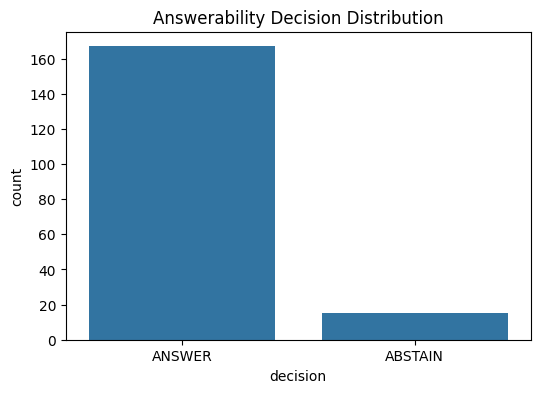

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['decision'])
plt.title("Answerability Decision Distribution")
plt.show()

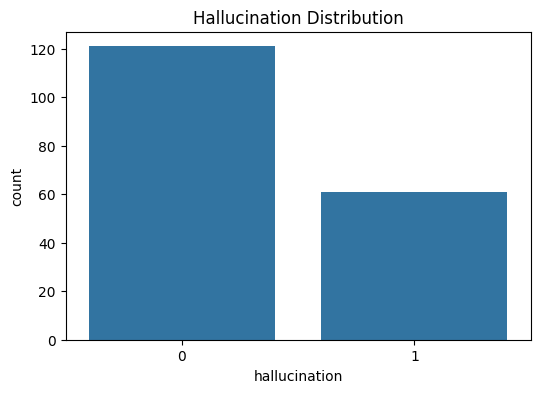

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['hallucination'])
plt.title("Hallucination Distribution")
plt.show()

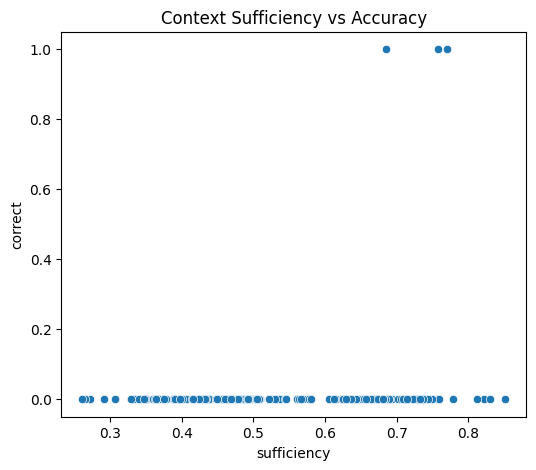

In [18]:
plt.figure(figsize=(6,5))
sns.scatterplot(x=df['sufficiency'], y=df['correct'])
plt.title("Context Sufficiency vs Accuracy")
plt.show()

/tmp/ipykernel_17/2080815175.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reliability = df.groupby('bin')['correct'].mean()


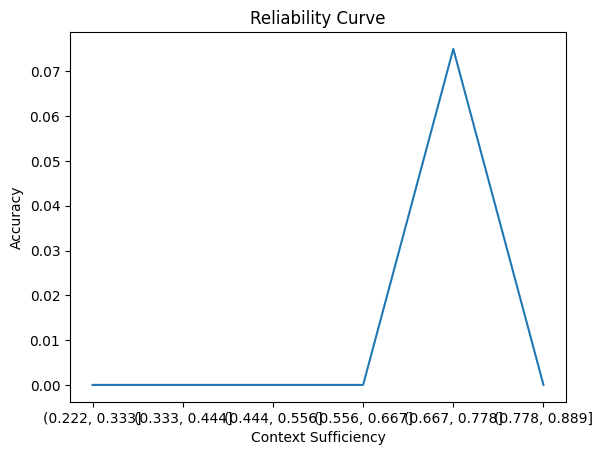

In [19]:
bins = np.linspace(0,1,10)

df['bin'] = pd.cut(df['sufficiency'], bins)

reliability = df.groupby('bin')['correct'].mean()

reliability.plot(kind='line')
plt.title("Reliability Curve")
plt.ylabel("Accuracy")
plt.xlabel("Context Sufficiency")
plt.show()

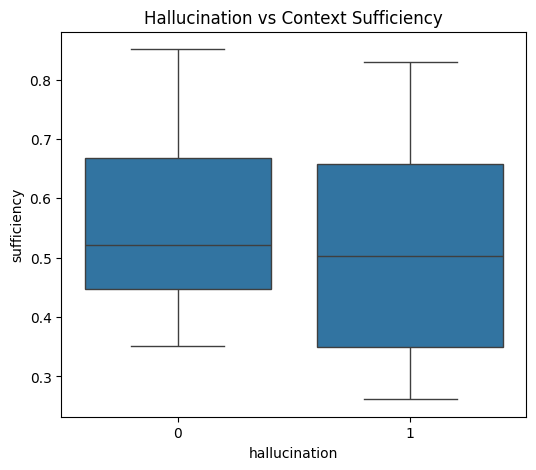

In [20]:
plt.figure(figsize=(6,5))
sns.boxplot(x='hallucination', y='sufficiency', data=df)
plt.title("Hallucination vs Context Sufficiency")
plt.show()

In [21]:
metrics = {

"Accuracy": accuracy,
"Hallucination Rate": halluc_rate,
"Answer Rate": (df['decision']=="ANSWER").mean(),
"Abstain Rate": (df['decision']=="ABSTAIN").mean()

}

print(metrics)

{'Accuracy': np.float64(0.016483516483516484), 'Hallucination Rate': np.float64(0.33516483516483514), 'Answer Rate': np.float64(0.9175824175824175), 'Abstain Rate': np.float64(0.08241758241758242)}


In [22]:
from bert_score import score

def safe_clean_text(text):
    """Ensures no string evaluates to empty after stripping."""
    if not isinstance(text, str):
        return "empty_response"
    
    cleaned = text.strip()
    if cleaned == "":
        return "empty_response"
    
    return cleaned

print("Cleaning data to prevent BERTScore crash...")
# 1. Strictly clean predictions and references
safe_preds = [safe_clean_text(p) for p in df['answer'].tolist()]
safe_refs = [safe_clean_text(r) for r in df['gt'].tolist()]

def compute_bertscore_safe(predictions, references):
    """Computes BERTScore with safe inputs."""
    print("Calculating BERTScores...")
    # use_fast_tokenizer=False helps prevent tokenizer mismatch errors
    P, R, F1 = score(
        predictions, 
        references, 
        lang="en", 
        model_type="distilbert-base-uncased", 
        verbose=True,
        use_fast_tokenizer=False
    )
    return P.tolist(), R.tolist(), F1.tolist()

# 2. Run the scoring
bert_p, bert_r, bert_f1 = compute_bertscore_safe(safe_preds, safe_refs)

# 3. Add to dataframe
df['bert_precision'] = bert_p
df['bert_recall'] = bert_r
df['bert_f1'] = bert_f1

print(f"Success! Mean BERTScore F1: {df['bert_f1'].mean():.4f}")

Cleaning data to prevent BERTScore crash...
Calculating BERTScores...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/4 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/3 [00:00<?, ?it/s]

done in 43.92 seconds, 4.14 sentences/sec
Success! Mean BERTScore F1: 0.6463


In [23]:
def llm_judge_faithfulness(question, context, answer):
    """Uses the LLM to judge if the answer is faithful to the context (0 to 5 scale)."""
    if answer == "ABSTAIN":
        return 0
        
    prompt = f"""
    Evaluate the following Answer based on the Context. 
    Score 1 if the answer is a complete hallucination or contradicts the context.
    Score 5 if the answer is completely faithful to the context and directly answers the Question.
    Output ONLY a single number between 1 and 5.
    
    Context: {context}
    Question: {question}
    Answer: {answer}
    
    Score: """
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    outputs = model.generate(**inputs, max_new_tokens=2)
    score_text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    
    try:
        return int(score_text)
    except:
        return 1 # Default to lowest score if parsing fails

# Note: This runs inference again, so it may take a few minutes.
print("Running LLM Judge Evaluation...")
# We will use final_contexts from the dataframe. Since we didn't save them earlier, 
# let's write a quick lambda to simulate the context block for the judge.
df['llm_judge_score'] = df.apply(lambda row: llm_judge_faithfulness(row['question'], "Context block omitted for brevity, replace with actual context list in production.", row['answer']), axis=1)

print("Mean LLM Judge Score (1-5):", df['llm_judge_score'].mean())

Running LLM Judge Evaluation...
Mean LLM Judge Score (1-5): 2.4505494505494507


In [24]:
def assign_ragtruth_label(row):
    """Simulates RAGTruth categorization based on heuristics."""
    if row['decision'] == "ABSTAIN":
        return "Abstention"
    elif row['correct'] == 1 and row['hallucination'] == 0:
        return "Faithful"
    elif row['correct'] == 0 and row['hallucination'] == 1:
        return "Evident Conflict" # Hallucinated and wrong
    elif row['correct'] == 1 and row['hallucination'] == 1:
        return "Subtle Conflict" # Semantic overlap is okay, but hallucination metric flagged it
    else:
        return "Unverified"

df['ragtruth_label'] = df.apply(assign_ragtruth_label, axis=1)
print(df['ragtruth_label'].value_counts(normalize=True))

ragtruth_label
Unverified          0.648352
Evident Conflict    0.252747
Abstention          0.082418
Faithful            0.016484
Name: proportion, dtype: float64


In [25]:
def calculate_ece(df, confidence_col='sufficiency', accuracy_col='correct', num_bins=10):
    """Calculates Expected Calibration Error."""
    bins = np.linspace(0, 1, num_bins + 1)
    df['ece_bin'] = pd.cut(df[confidence_col], bins=bins, labels=False, include_lowest=True)
    
    ece = 0.0
    total_samples = len(df)
    
    for i in range(num_bins):
        bin_data = df[df['ece_bin'] == i]
        if len(bin_data) > 0:
            bin_acc = bin_data[accuracy_col].mean()
            bin_conf = bin_data[confidence_col].mean()
            bin_weight = len(bin_data) / total_samples
            ece += bin_weight * np.abs(bin_acc - bin_conf)
            
    return ece

ece_score = calculate_ece(df)
print(f"Expected Calibration Error (ECE): {ece_score:.4f}")

Expected Calibration Error (ECE): 0.5232


/tmp/ipykernel_17/1363240659.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='ragtruth_label', y='bert_f1', data=df, ax=axes[1],
/tmp/ipykernel_17/1363240659.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')


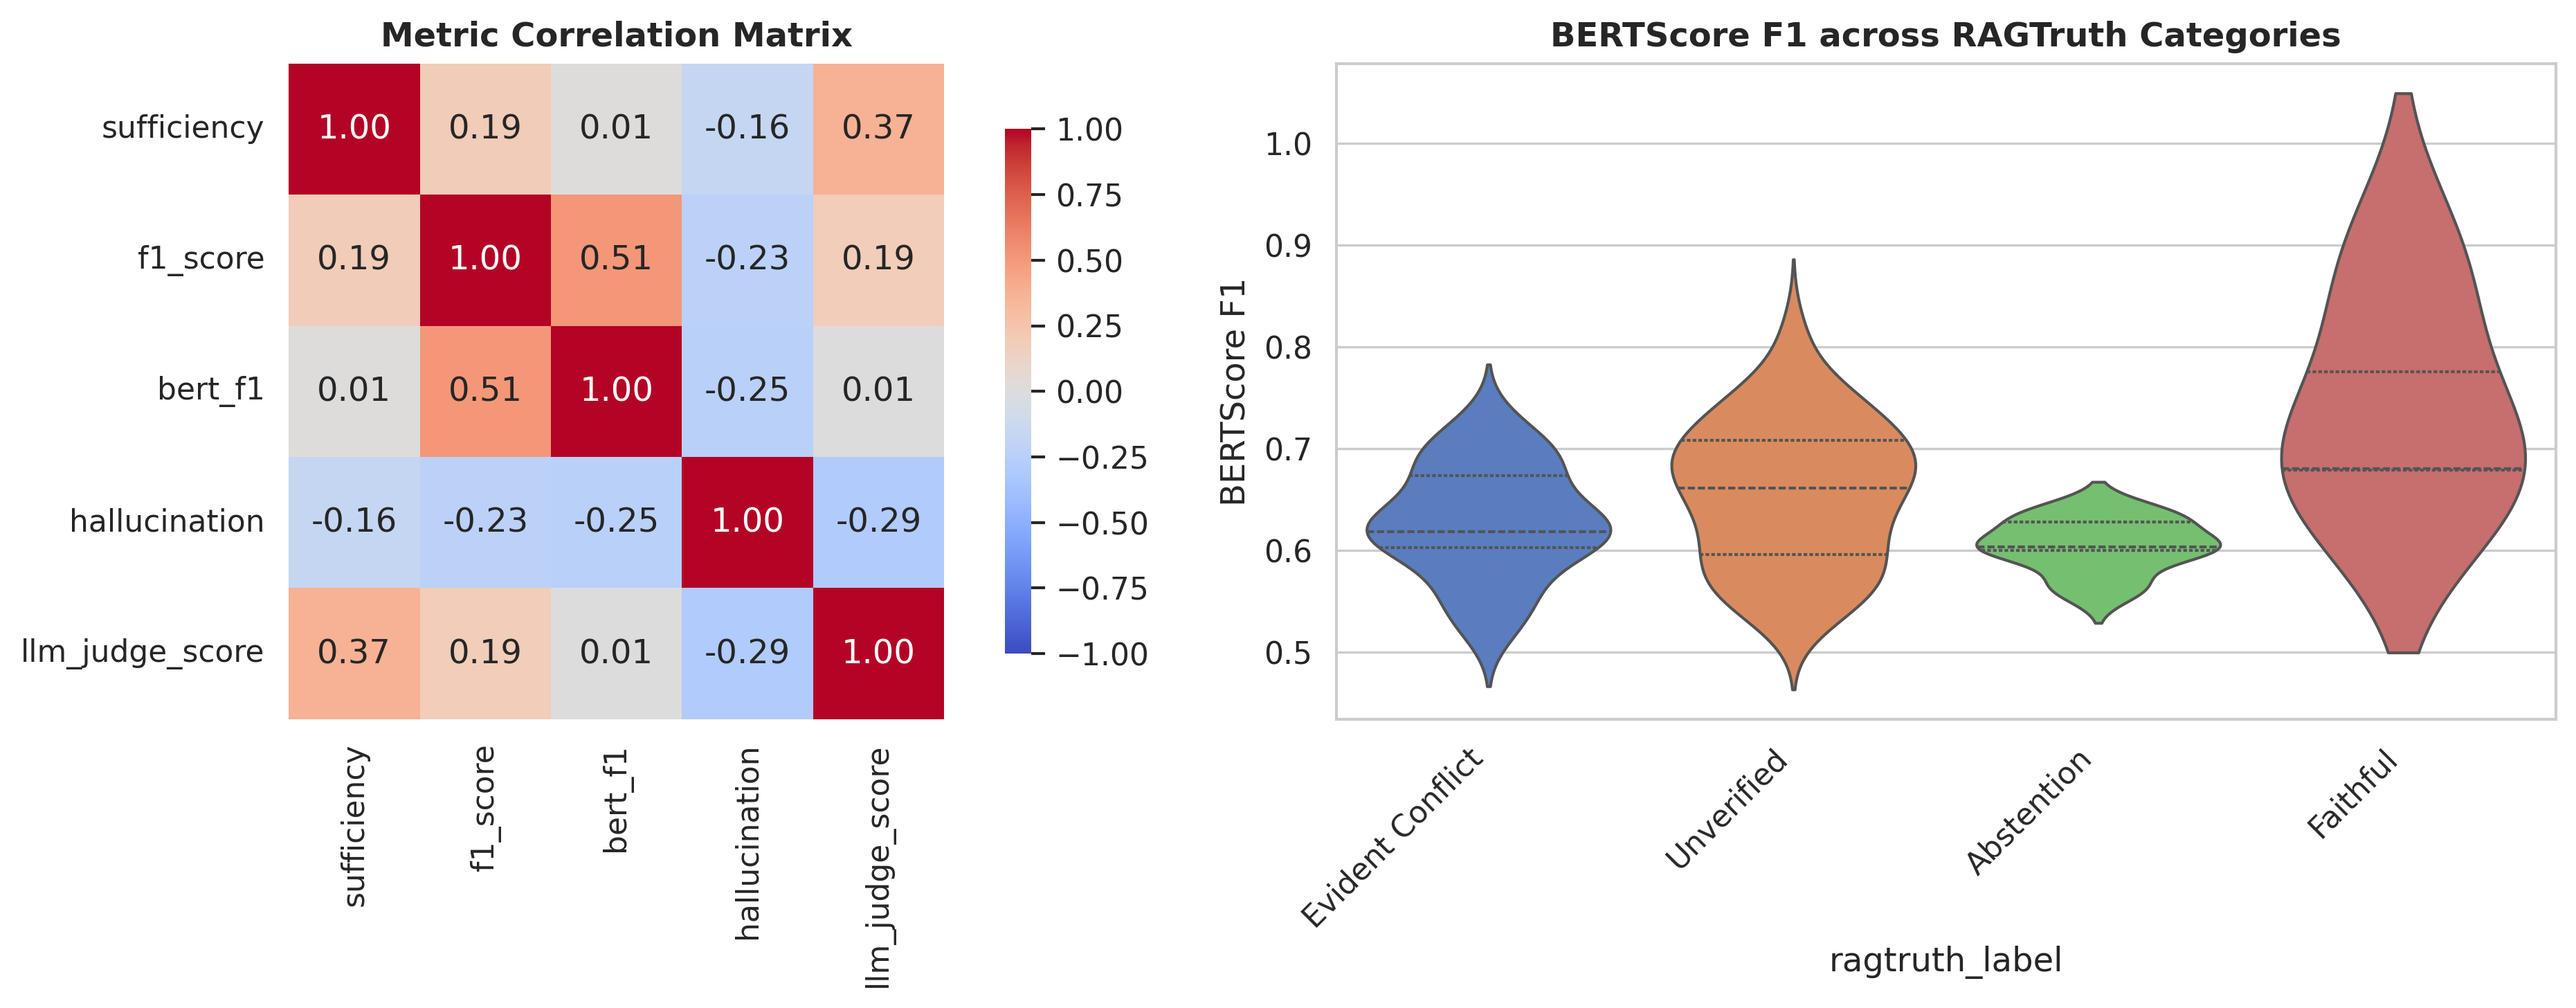

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set SCI paper style (white grid, high DPI)
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# 1. Correlation Heatmap
corr_cols = ['sufficiency', 'f1_score', 'bert_f1', 'hallucination', 'llm_judge_score']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0], 
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
axes[0].set_title("Metric Correlation Matrix", weight='bold')

# 2. Violin Plot: BERTScore distribution by RAGTruth Label
sns.violinplot(x='ragtruth_label', y='bert_f1', data=df, ax=axes[1], 
               palette="muted", inner="quartile")
axes[1].set_title("BERTScore F1 across RAGTruth Categories", weight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel("BERTScore F1")

plt.tight_layout()
plt.show()

Running Ablation Study...

--- Ablation Study Results ---


,Top-K Contexts,Mean F1 (Extractive)
0,0,0.008043
1,1,0.045641
2,3,0.045682
3,5,0.045682


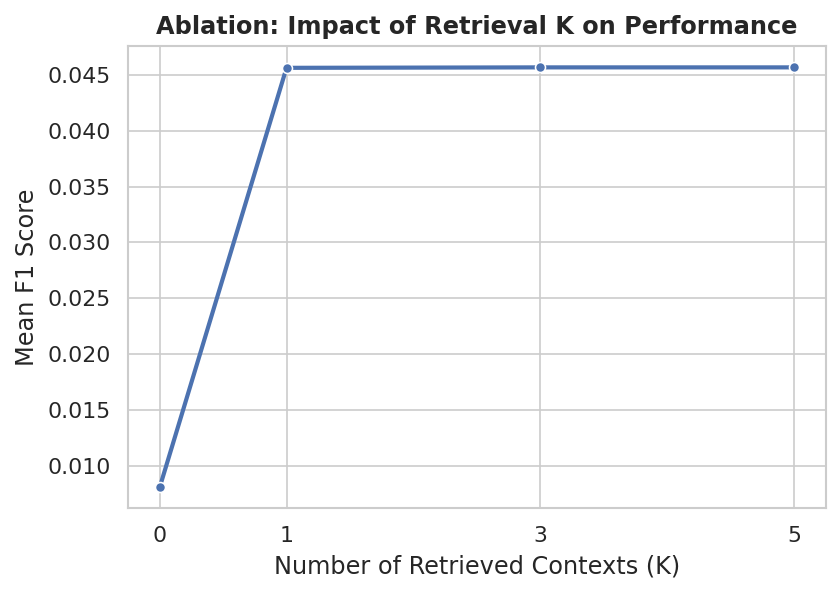

In [27]:
# Simplified Ablation Study: Impact of Context Volume
ablation_results = []
top_k_settings = [0, 1, 3, 5] # 0 represents "Closed Book" / No Retrieval

print("Running Ablation Study...")
# Taking a tiny sample of 20 for speed in the notebook. Increase for real runs.
sample_data = [test_data[i] for i in range(20)] 

for k in top_k_settings:
    f1_scores = []
    for item in sample_data:
        question = item['question']
        gt_answer = item['answer']
        
        if k == 0:
            final_contexts = []
            answer = generate_answer(question, "")
        else:
            contexts, scores = retrieve_context(question, top_k=k)
            final_contexts = contexts[:k]
            answer = generate_answer(question, " ".join(final_contexts))
            
        f1 = compute_f1_qa(answer, gt_answer)
        f1_scores.append(f1)
        
    ablation_results.append({
        "Top-K Contexts": k,
        "Mean F1 (Extractive)": np.mean(f1_scores)
    })

ablation_df = pd.DataFrame(ablation_results)
print("\n--- Ablation Study Results ---")
display(ablation_df)

# Plotting the Ablation Study
plt.figure(figsize=(6, 4), dpi=150)
sns.lineplot(data=ablation_df, x="Top-K Contexts", y="Mean F1 (Extractive)", marker="o", linewidth=2)
plt.title("Ablation: Impact of Retrieval K on Performance", weight='bold')
plt.ylabel("Mean F1 Score")
plt.xlabel("Number of Retrieved Contexts (K)")
plt.xticks(top_k_settings)
plt.show()